In [2]:
import pandas as pd

In [5]:
# cari folder directori file yang akan di olah

df_npl = pd.read_csv(r'C:\Users\advan\Downloads\Czech Bank Financial Dataset\npl_ratio_summary.csv')

In [6]:
df_npl.head()

,periode,npl_outstanding,total_penyaluran_outstanding,npl_ratio
0,199307,96396,389436,24.75
1,199308,96396,495240,19.46
2,199309,271140,1085352,24.98
3,199310,271140,1239768,21.87
4,199311,271140,1458324,18.59


In [7]:
df_npl.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   periode                       66 non-null     int64  
 1   npl_outstanding               66 non-null     int64  
 2   total_penyaluran_outstanding  66 non-null     int64  
 3   npl_ratio                     66 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 2.2 KB


In [8]:
# 1. Ubah kolom periode menjadi teks (str), lalu konversi ke tipe data tanggal (datetime)
# Parameter format='%Y%m' memberi tahu Pandas urutannya: YYYY (Tahun) dan MM (Bulan)


df_npl['periode'] = pd.to_datetime(df_npl['periode'].astype(str),format='%Y%m')

In [9]:
df_npl.head()

,periode,npl_outstanding,total_penyaluran_outstanding,npl_ratio
0,1993-07-01,96396,389436,24.75
1,1993-08-01,96396,495240,19.46
2,1993-09-01,271140,1085352,24.98
3,1993-10-01,271140,1239768,21.87
4,1993-11-01,271140,1458324,18.59


In [10]:
df_npl.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   periode                       66 non-null     datetime64[us]
 1   npl_outstanding               66 non-null     int64         
 2   total_penyaluran_outstanding  66 non-null     int64         
 3   npl_ratio                     66 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 2.2 KB


In [ ]:
#  TAHAP SELANJUTNYA Data Visualization (Visualisasi Data) di Python

In [11]:
import matplotlib.pyplot as plt

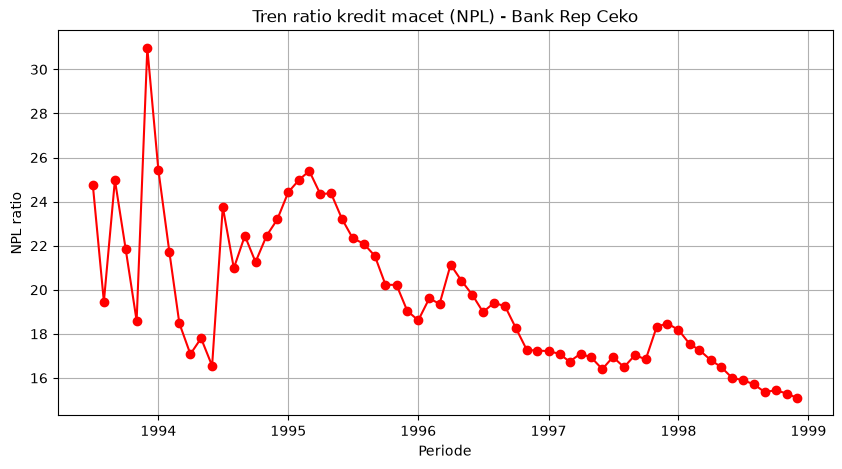

In [24]:
plt.figure(figsize=(10,5))                                                      #--> Menyiapkan ukuran kanvas (lebar 10, tinggi 5)
plt.plot(df_npl['periode'], df_npl['npl_ratio'], marker='o', color='red')       #--> Menggambar grafik garis (Sumbu X = periode, Sumbu Y = npl_ratio)
plt.title('Tren ratio kredit macet (NPL) - Bank Rep Ceko')                      #--> Memberi judul utama (atas)
plt.xlabel('Periode')                                                           #--> Memberi judul sumbu x 
plt.ylabel('NPL ratio')                                                         #--> Memberi judul sumbu y
plt.grid(True)                                                                  #--> Menambah garis bantu (vertikal dan horizontal) 
plt.show()                                                                      #--> Menampilkan hasil akhir

In [28]:
# Membuat dataset makroekonomi (Tingkat Pengangguran)

data_makro = {
    'periode': pd.to_datetime(['1993-07-01', '1993-08-01', '1993-09-01', '1993-10-01', '1993-11-01', '1993-12-01']),
    'pengangguran' : [4.2, 4.3, 5.1, 5.2, 5.5, 6.8]             #--> angka simulasi dalam persentase
     }
df_makro = pd.DataFrame(data_makro)

In [29]:
# Menggabungkan merge data npl dengan data makro berdasarkan kolom 'periode'
# Ini ekuivalen dengan : SELECT * FROM df_npl INNER JOIN df_makro ON df_npl.periode = df_makro.periode

df_gabungan = pd.merge(df_npl, df_makro, on='periode', how='inner')
df_gabungan[['periode', 'npl_ratio', 'pengangguran']]

,periode,npl_ratio,pengangguran
0,1993-07-01,24.75,4.2
1,1993-08-01,19.46,4.3
2,1993-09-01,24.98,5.1
3,1993-10-01,21.87,5.2
4,1993-11-01,18.59,5.5
5,1993-12-01,30.97,6.8


In [30]:
# Menghitung korelasi Pearson antara Rasio NPL dan Tingkat Pengangguran

skor_korelasi = df_gabungan['npl_ratio'].corr(df_gabungan['pengangguran'])
print (f'Skor korelasi NPL vs Pengangguran = {skor_korelasi:.2f}')

Skor korelasi NPL vs Pengangguran = 0.59


In [32]:
alamat_simpan = r'C:\Users\advan\Downloads\Czech Bank Financial Dataset\npl_makro_gabungan.csv'
df_gabungan.to_csv(alamat_simpan, index=False)